<a href="https://colab.research.google.com/github/VICO-27/colab-notebooks/blob/main/GeoAI_Aquaculture_Challenge-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================
# Import Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns

from pathlib import Path

# Plot style
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ============================================
# Load Dataset
# ============================================
train = pd.read_csv("/content/drive/MyDrive/Train.csv")
test = pd.read_csv("/content/drive/MyDrive/Test.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

Train Shape : (1821, 146)
Test Shape  : (1030, 145)


In [6]:
# ============================================
# First Five Rows
# ============================================

train.head()

,ID,label,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,re3_01,red_01,swir1_01,swir2_01,VH_02,VV_02,blue_02,green_02,nir_02,nira_02,re1_02,re2_02,re3_02,red_02,swir1_02,swir2_02,VH_03,VV_03,blue_03,green_03,nir_03,nira_03,re1_03,re2_03,re3_03,red_03,swir1_03,swir2_03,VH_04,VV_04,blue_04,green_04,nir_04,nira_04,re1_04,re2_04,re3_04,red_04,swir1_04,swir2_04,VH_05,VV_05,blue_05,green_05,nir_05,nira_05,re1_05,re2_05,re3_05,red_05,swir1_05,swir2_05,VH_06,VV_06,blue_06,green_06,nir_06,nira_06,re1_06,re2_06,re3_06,red_06,swir1_06,swir2_06,VH_07,VV_07,blue_07,green_07,nir_07,nira_07,re1_07,re2_07,re3_07,red_07,swir1_07,swir2_07,VH_08,VV_08,blue_08,green_08,nir_08,nira_08,re1_08,re2_08,re3_08,red_08,swir1_08,swir2_08,VH_09,VV_09,blue_09,green_09,nir_09,nira_09,re1_09,re2_09,re3_09,red_09,swir1_09,swir2_09,VH_10,VV_10,blue_10,green_10,nir_10,nira_10,re1_10,re2_10,re3_10,red_10,swir1_10,swir2_10,VH_11,VV_11,blue_11,green_11,nir_11,nira_11,re1_11,re2_11,re3_11,red_11,swir1_11,swir2_11,VH_12,VV_12,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
0,ID_TR_NEW_XVGKFMLNRJ,0,-29.099645,-22.471573,1665,1719,1367,1270,1689,1416,1379,1705,1154,1141,-30.293645,-23.248797,1641,1815,1339,1253,1704,1352,1349,1785,1218,1172,-25.825494,-23.336230,2081,2396,2117,1957,2606,2219,2205,2560,1287,1190,-28.604696,-21.748391,2025,2275,2116,1978,2522,2204,2243,2500,1218,1169,-27.125389,-21.379764,2187,2372,2310,2252,2450,2301,2356,2424,1374,1240,-36.058930,-21.861530,2016,2213,1525,1448,2230,1641,1652,2226,1226,1183,-30.026146,-22.419230,1704,1885,1365,1311,1774,1386,1416,1824,1350,1286,-28.345876,-22.290760,1659,1895,1303,1277,1718,1324,1362,1731,1340,1282,-25.347438,-20.290513,1862,2084,2030,1953,2176,1990,2035,2100,1208,1152,-30.503403,-23.955628,1781,2029,1641,1517,2070,1720,1721,1949,1246,1183,-28.004794,-22.499798,1745,1917,1419,1384,1727,1439,1460,1710,1280,1193,-27.869169,-19.631005,1639,1826,1395,1384,1736,1449,1436,1626,1307,1216
1,ID_TR_NEW_GP8KNSWVP6,0,-19.470574,-10.752340,1579,1740,2245,2231,2060,2147,2161,1968,2554,2422,-18.745639,-8.814224,1328,1519,1942,1918,1747,1802,1837,1708,2176,2040,-21.769029,-9.850741,1679,1860,2434,2406,2165,2275,2365,2020,2508,2287,-20.684984,-10.697351,2045,2354,3050,3055,2845,2882,2969,2689,3348,3107,-18.440298,-9.918211,1995,2319,3176,3257,2840,3039,3166,2597,3438,3169,-15.908768,-9.146760,1706,2000,4128,4251,2504,4029,4210,1990,3194,2518,-15.996166,-6.585548,1381,1837,6567,6546,2414,5762,6463,1436,3174,2075,-15.421053,-6.385984,1360,1855,6266,6373,2574,5564,6202,1412,3028,1913,-13.722553,-6.280759,1356,1750,5260,5364,2550,4620,5087,1451,2792,1811,-15.806885,-9.103828,1545,1714,3928,4155,2504,3470,3732,1711,2964,2085,-18.138170,-11.374729,1366,1509,2761,2897,2010,2403,2623,1570,2899,2389,-18.873062,-10.972313,1490,1622,2090,2109,1924,1941,2020,1779,2298,2131
2,ID_TR_NEW_87X3957MVS,1,-20.964854,-8.792675,1850,2345,3664,3470,2935,3384,3451,2032,3189,2397,-22.723501,-10.669983,1982,2266,3235,3070,2646,2955,3030,2161,2477,1792,-32.265795,-22.276882,1782,2105,1337,1298,1740,1391,1398,1790,1314,1227,-26.606786,-20.089431,1609,1791,1240,1213,1483,1287,1246,1518,1300,1212,-28.613416,-22.524134,1437,1684,1448,1579,1679,1504,1623,1508,1508,1368,-27.579135,-21.463103,1820,2153,1727,1659,2232,1785,1855,1947,1544,1407,-27.423641,-20.238467,1906,2241,1837,1756,2324,1870,1987,1975,1577,1433,-29.585175,-20.128795,1492,1906,1519,1482,1988,1563,1618,1650,1444,1298,-32.687598,-19.338749,1609,2016,1819,1708,2240,1933,2004,1816,1459,1333,-31.181865,-22.534477,1537,1817,1545,1563,1872,1632,1688,1590,1303,1218,-30.228160,-22.283716,1586,1808,1586,1527,1815,1642,1612,1578,1349,1254,-28.710411,-20.065031,1438,1673,1335,1289,1588,1377,1307,1503,1237,1168
3,ID_TR_NEW_T4JMRPKHS3,0,-18.728208,-4.689202,1279,1297,1713,1698,1527,1531,1590,1468,1669,1421,-17.384014,-5.642187,1263,1348,1771,1697,1544,1563,1605,1518,1755,1472,-19.614806,-4.230588,1301,1345,1649,1569,1501,1480,1525,1447,1638,1430,-17.334069,-3.

In [7]:
# ============================================
# Dataset Information
# ============================================

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1821 entries, 0 to 1820
Columns: 146 entries, ID to swir2_12
dtypes: float64(24), int64(121), object(1)
memory usage: 2.0+ MB


In [8]:
train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1821 entries, 0 to 1820
Data columns (total 146 columns):
 #    Column    Dtype  
---   ------    -----  
 0    ID        object 
 1    label     int64  
 2    VH_01     float64
 3    VV_01     float64
 4    blue_01   int64  
 5    green_01  int64  
 6    nir_01    int64  
 7    nira_01   int64  
 8    re1_01    int64  
 9    re2_01    int64  
 10   re3_01    int64  
 11   red_01    int64  
 12   swir1_01  int64  
 13   swir2_01  int64  
 14   VH_02     float64
 15   VV_02     float64
 16   blue_02   int64  
 17   green_02  int64  
 18   nir_02    int64  
 19   nira_02   int64  
 20   re1_02    int64  
 21   re2_02    int64  
 22   re3_02    int64  
 23   red_02    int64  
 24   swir1_02  int64  
 25   swir2_02  int64  
 26   VH_03     float64
 27   VV_03     float64
 28   blue_03   int64  
 29   green_03  int64  
 30   nir_03    int64  
 31   nira_03   int64  
 32   re1_03    int64  
 33   re2_03    int64  
 34   re3_03    int64  
 35 

In [9]:
# ============================================
# Missing Values
# ============================================

missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

print("Train Missing Values :", missing_train.sum())
print("Test Missing Values  :", missing_test.sum())

Train Missing Values : 0
Test Missing Values  : 0


In [10]:
# ============================================
# Duplicate Rows
# ============================================

print("Duplicate Train Rows :", train.duplicated().sum())
print("Duplicate Test Rows  :", test.duplicated().sum())

Duplicate Train Rows : 0
Duplicate Test Rows  : 0


,count
label,
0,1086
1,735


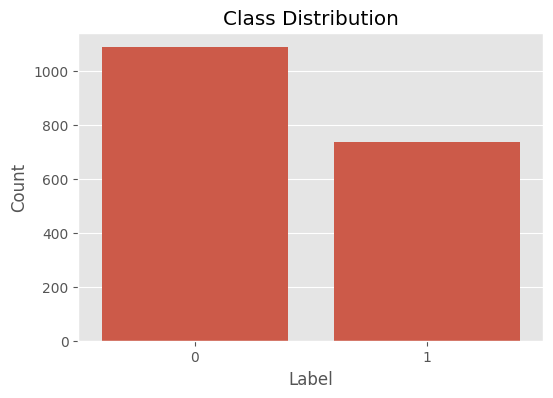

In [11]:
# ============================================
# Target Distribution
# ============================================

counts = train["label"].value_counts().sort_index()

display(counts)

plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="label"
)

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [12]:
# ============================================
# Percentage Distribution
# ============================================

(train["label"]
 .value_counts(normalize=True)
 .rename("Percentage")
 *100)

,Percentage
label,
0,59.637562
1,40.362438


In [13]:
# ============================================
# Organize Feature Groups
# ============================================

bands = [
    "VH","VV",
    "blue","green",
    "nir","nira",
    "re1","re2","re3",
    "red",
    "swir1","swir2"
]

months = [f"{i:02d}" for i in range(1,13)]

feature_columns = []

for band in bands:
    for month in months:
        feature_columns.append(f"{band}_{month}")

print("Total Features:", len(feature_columns))
feature_columns[:10]

Total Features: 144


['VH_01',
 'VH_02',
 'VH_03',
 'VH_04',
 'VH_05',
 'VH_06',
 'VH_07',
 'VH_08',
 'VH_09',
 'VH_10']

In [14]:
# ============================================
# Descriptive Statistics
# ============================================

train[feature_columns].describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
VH_01,1821.0,-25.379836,5.586461,-48.143182,-29.510694,-23.945252,-21.090626,-10.404720
VH_02,1821.0,-25.704491,5.763436,-47.843876,-30.049040,-24.426500,-21.052992,-10.918949
VH_03,1821.0,-26.844063,5.670426,-46.797621,-31.301293,-27.071016,-21.896081,-10.983199
VH_04,1821.0,-25.956827,6.480113,-46.609843,-31.378632,-27.119190,-19.778938,-9.692008
VH_05,1821.0,-25.454404,6.628050,-48.410895,-30.803085,-26.719746,-19.331963,-10.500833
VH_06,1821.0,-26.012238,6.567386,-48.178777,-31.277560,-27.391588,-19.410776,-8.929224
VH_07,1821.0,-26.037826,6.825690,-48.162396,-31.293377,-27.716078,-19.363662,-10.580417
VH_08,1821.0,-25.595282,6.695342,-45.130620,-30.996624,-27.517323,-19.300067,-11.647235
VH_09,1821.0,-24.830118,6.782401,-48.163944,-30.137913,-25.964900,-18.862825,-10.328396
VH_10,1821.0,-24.761956,6.596195,-48.196000,-30.352656,-24.143138,-19.344139,-10.393013


DENSE STATISTICAL SUMMARY BY LABEL
label                     0            1
VH_01    count  1086.000000   735.000000
         mean    -24.494737   -26.687616
         std       5.711710     5.127142
         min     -48.143182   -46.009054
         25%     -28.654692   -30.551445
         50%     -22.478794   -26.041416
         75%     -20.343313   -22.544744
         max     -10.404720   -14.911059
VV_01    count  1086.000000   735.000000
         mean    -15.083692   -15.215269
         std       5.744177     5.646998
         min     -31.912804   -26.979739
         25%     -18.563439   -21.397203
         50%     -13.320842   -13.245330
         75%     -11.049613   -10.430086
         max       6.227268    -5.201235
nir_01   count  1086.000000   735.000000
         mean   2355.511050  2262.070748
         std     914.198391   797.383315
         min    1011.000000  1076.000000
         25%    1650.500000  1360.000000
         50%    2259.000000  2520.000000
         75%    2846.5

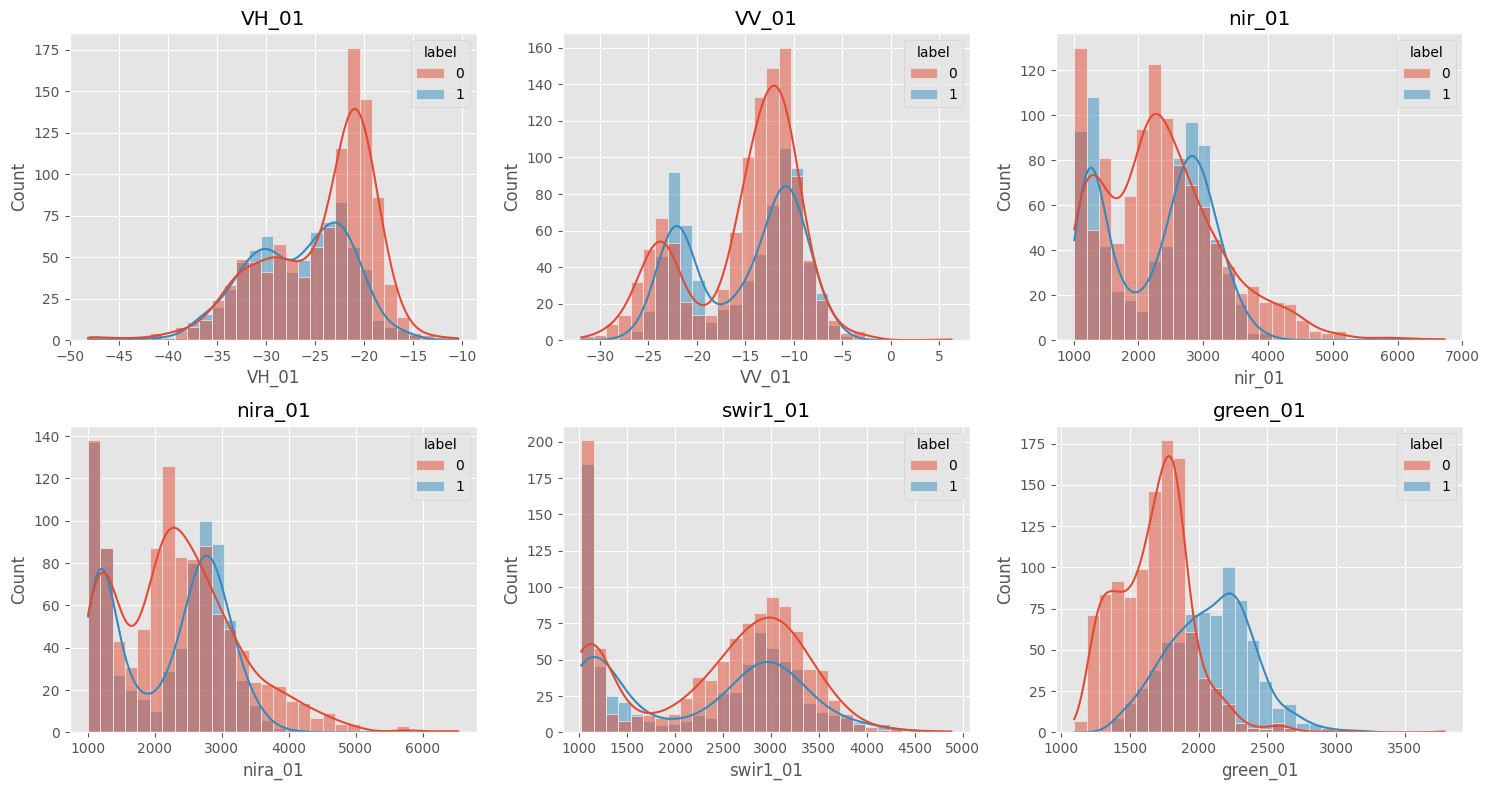

FEATURE OVERLAP ANALYSIS
Feature: VH_01      | Distribution Overlap: 70.4%
  -> Interpretation: High Overlap. Poor separator on its own.
------------------------------------------------------------
Feature: VV_01      | Distribution Overlap: 70.9%
  -> Interpretation: High Overlap. Poor separator on its own.
------------------------------------------------------------
Feature: nir_01     | Distribution Overlap: 60.9%
  -> Interpretation: Moderate Overlap. Some predictive power.
------------------------------------------------------------
Feature: nira_01    | Distribution Overlap: 63.7%
  -> Interpretation: Moderate Overlap. Some predictive power.
------------------------------------------------------------
Feature: swir1_01   | Distribution Overlap: 75.0%
  -> Interpretation: High Overlap. Poor separator on its own.
------------------------------------------------------------
Feature: green_01   | Distribution Overlap: 42.4%
  -> Interpretation: Moderate Overlap. Some predictive power

In [15]:
portant_features = ["VH_01", "VV_01", "nir_01", "nira_01", "swir1_01", "green_01"]

# 1. GENERATE AND PRINT THE TEXT/TABULAR SUMMARY
print("=" * 60)
print("DENSE STATISTICAL SUMMARY BY LABEL")
print("=" * 60)


important_features = [
    "VH_01",
    "VV_01",
    "nir_01",
    "nira_01",
    "swir1_01",
    "green_01"
]

# This groups the data by 'label', grabs your features, and gets summary stats
summary_table = train.groupby("label")[important_features].describe().T
print(summary_table.to_string())

print("\n" + "=" * 60 + "\n")


# 2. GENERATE THE VISUALIZATION
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.ravel(), important_features):
    sns.histplot(data=train, x=feature, hue="label", kde=True, ax=ax, bins=30)
    ax.set_title(feature)

plt.tight_layout()
plt.show()



print("=" * 60)
print("FEATURE OVERLAP ANALYSIS")
print("=" * 60)

for feature in important_features:
    # Separate the data by label
    group0 = train[train["label"] == 0][feature].dropna()
    group1 = train[train["label"] == 1][feature].dropna()

    # Get a shared range for the bins
    low = min(group0.min(), group1.min())
    high = max(group0.max(), group1.max())

    # Compute histograms with identical bins
    hist0, _ = np.histogram(group0, bins=100, range=(low, high), density=True)
    hist1, _ = np.histogram(group1, bins=100, range=(low, high), density=True)

    # Calculate the overlapping area
    overlap = np.minimum(hist0, hist1).sum() * (high - low) / 100
    overlap_pct = overlap * 100

    # Print the text breakdown
    print(f"Feature: {feature:<10} | Distribution Overlap: {overlap_pct:.1f}%")

    # Add a text-based explanation based on the percentage
    if overlap_pct > 70:
        print("  -> Interpretation: High Overlap. Poor separator on its own.")
    elif overlap_pct > 40:
        print("  -> Interpretation: Moderate Overlap. Some predictive power.")
    else:
        print(
            "  -> Interpretation: Low Overlap! Excellent feature for splitting labels."
        )
    print("-" * 60)

# (Your plotting code remains the same below this)

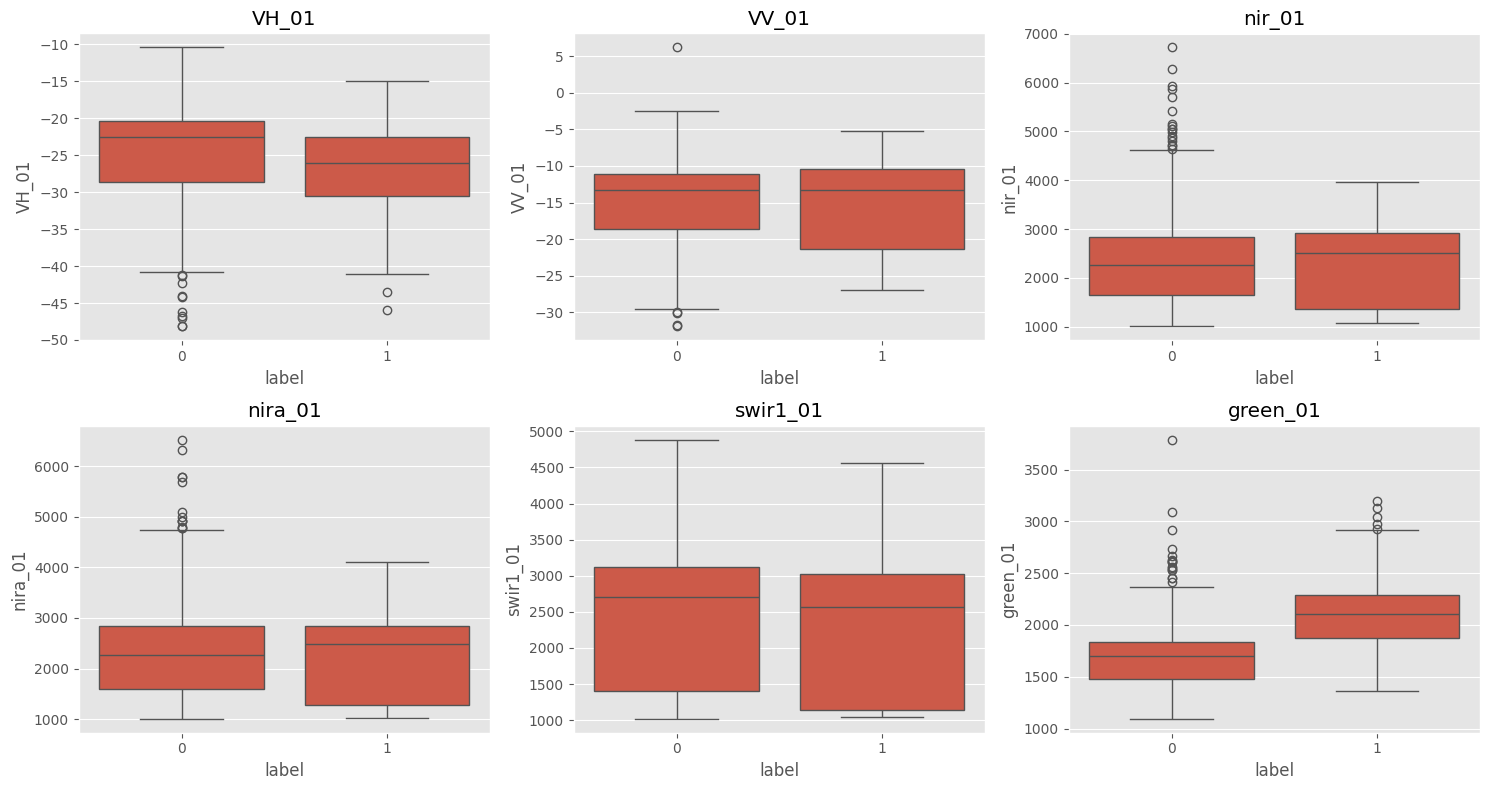

In [16]:
fig, axes = plt.subplots(2,3, figsize=(15,8))

for ax, feature in zip(axes.ravel(), important_features):

    sns.boxplot(
        data=train,
        x="label",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

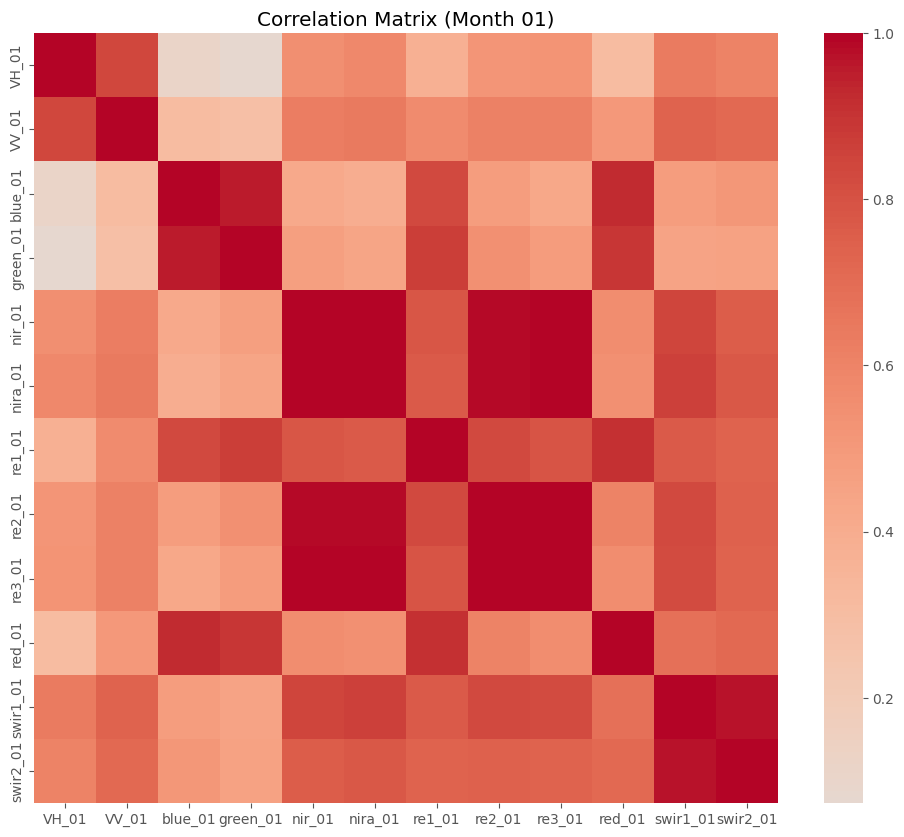

In [17]:
month1_features = [f"{band}_01" for band in bands]

corr = train[month1_features].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix (Month 01)")

plt.show()

In [18]:
results = []

for band in bands:

    cols = [f"{band}_{m}" for m in months]

    pond = train.loc[train.label==1, cols].values.mean()

    other = train.loc[train.label==0, cols].values.mean()

    results.append({

        "Band":band,

        "Pond Mean":pond,

        "Other Mean":other,

        "Difference":pond-other

    })

band_summary = pd.DataFrame(results)

band_summary

,Band,Pond Mean,Other Mean,Difference
0,VH,-29.155434,-23.052562,-6.102872
1,VV,-18.506644,-14.400385,-4.106259
2,blue,1761.946712,1632.961403,128.985309
3,green,2098.284694,1863.338244,234.946450
4,nir,1893.728571,2939.904389,-1046.175818
5,nira,1828.346145,2984.974908,-1156.628763
6,re1,2173.190249,2229.262738,-56.072488
7,re2,1899.818594,2711.612416,-811.793821
8,re3,1935.021769,2891.849448,-956.827679
9,red,1914.464172,1895.897790,18.566382


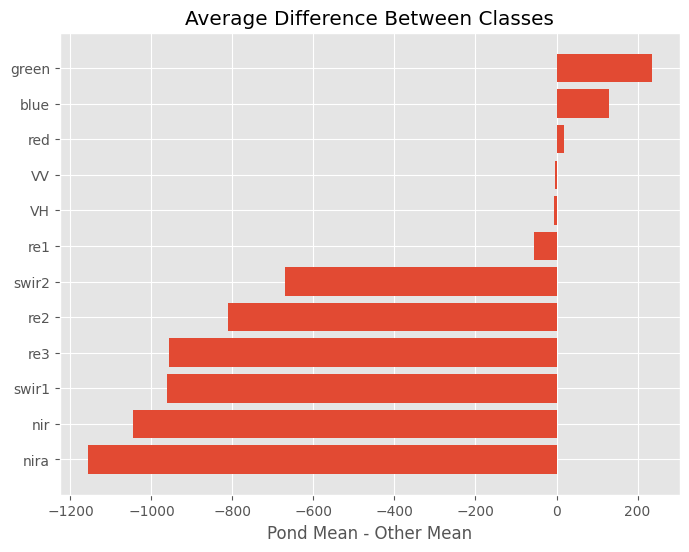

In [19]:
band_summary = band_summary.sort_values(
    "Difference"
)

plt.figure(figsize=(8,6))

plt.barh(
    band_summary["Band"],
    band_summary["Difference"]
)

plt.title("Average Difference Between Classes")

plt.xlabel("Pond Mean - Other Mean")

plt.show()

   Month     Pond    Other
0     01  2262.07  2355.51
1     02  2093.60  2509.41
2     03  1755.56  2664.38
3     04  1506.89  2982.09
4     05  1825.62  3039.77
5     06  1935.29  3283.30
6     07  1863.87  3511.48
7     08  1706.27  3662.19
8     09  1682.05  3330.40
9     10  1878.32  2934.40
10    11  2115.42  2564.55
11    12  2099.79  2441.37


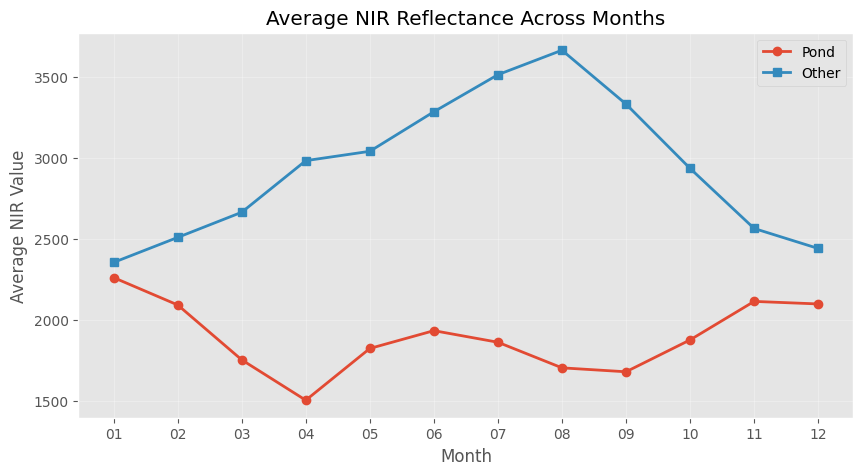

In [20]:
# ============================================
# Temporal EDA - Monthly NIR Trend
# ============================================

months = [f"{i:02d}" for i in range(1, 13)]

pond_means = []
other_means = []

for month in months:

    pond_mean = train.loc[
        train["label"] == 1,
        f"nir_{month}"
    ].mean()

    other_mean = train.loc[
        train["label"] == 0,
        f"nir_{month}"
    ].mean()

    pond_means.append(pond_mean)
    other_means.append(other_mean)

# Print values (easy for us to discuss later)
monthly_nir = pd.DataFrame({
    "Month": months,
    "Pond": np.round(pond_means, 2),
    "Other": np.round(other_means, 2)
})

print(monthly_nir)

# Plot
plt.figure(figsize=(10,5))

plt.plot(months, pond_means,
         marker="o",
         linewidth=2,
         label="Pond")

plt.plot(months, other_means,
         marker="s",
         linewidth=2,
         label="Other")

plt.title("Average NIR Reflectance Across Months")
plt.xlabel("Month")
plt.ylabel("Average NIR Value")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

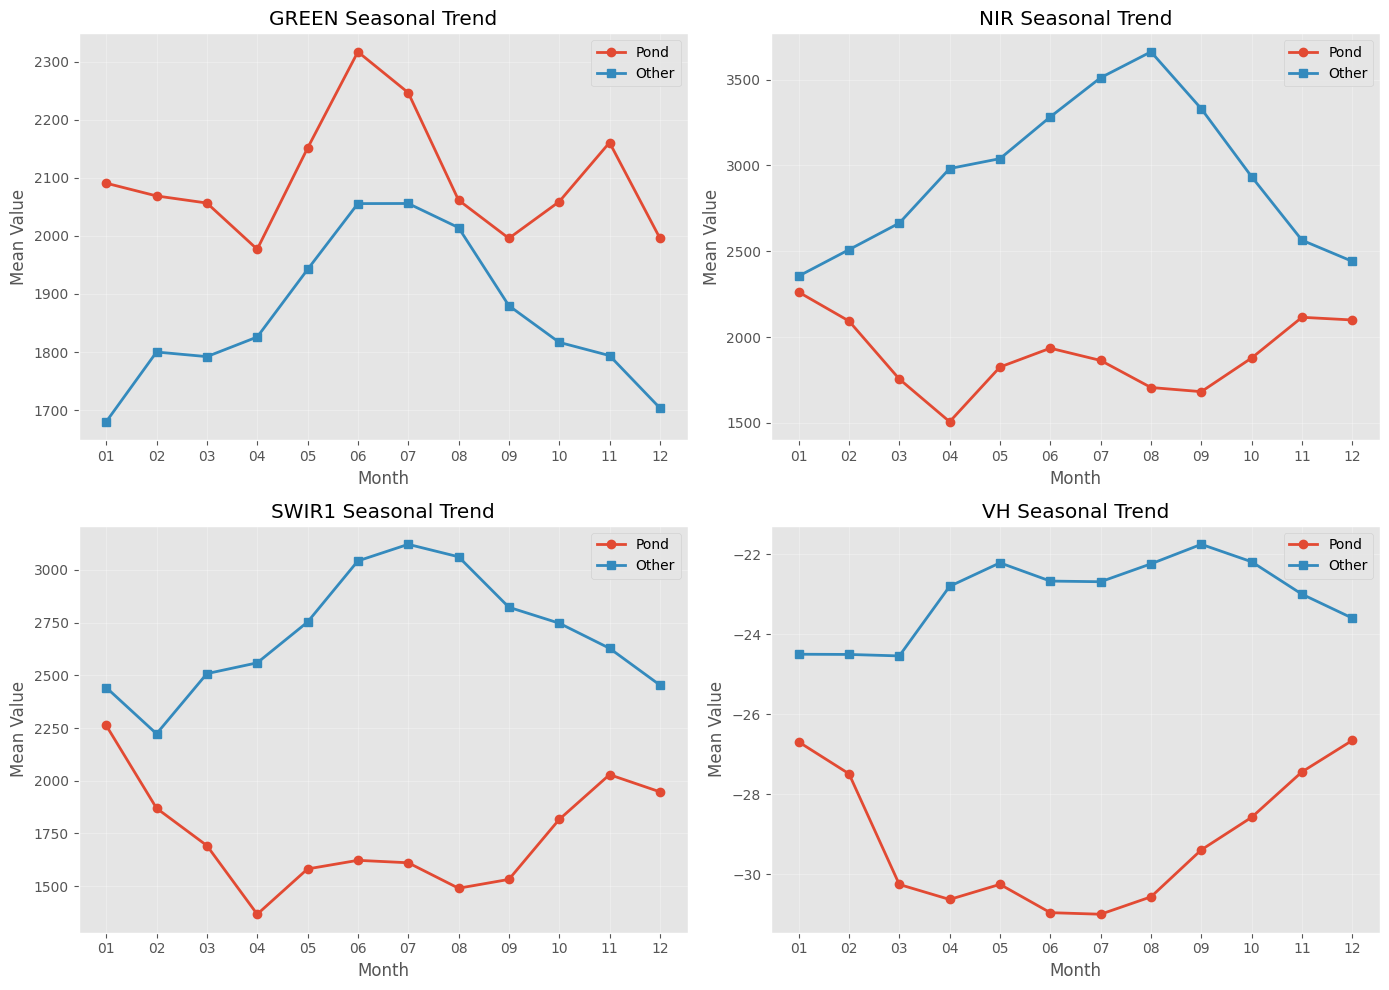

In [21]:
# ============================================
# Temporal EDA - Multi-Band Seasonal Trends
# ============================================

bands_to_plot = ["green", "nir", "swir1", "VH"]
months = [f"{i:02d}" for i in range(1, 13)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for ax, band in zip(axes, bands_to_plot):

    pond = []
    other = []

    for month in months:

        pond.append(
            train.loc[train["label"] == 1, f"{band}_{month}"].mean()
        )

        other.append(
            train.loc[train["label"] == 0, f"{band}_{month}"].mean()
        )

    ax.plot(months, pond,
            marker="o",
            linewidth=2,
            label="Pond")

    ax.plot(months, other,
            marker="s",
            linewidth=2,
            label="Other")

    ax.set_title(f"{band.upper()} Seasonal Trend")
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean Value")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [22]:
# ============================================
# Monthly Mean Table
# ============================================

bands_to_print = ["green", "nir", "swir1", "VH"]

months = [f"{i:02d}" for i in range(1, 13)]

for band in bands_to_print:

    pond = []
    other = []

    for month in months:

        pond.append(
            train.loc[train.label == 1, f"{band}_{month}"].mean()
        )

        other.append(
            train.loc[train.label == 0, f"{band}_{month}"].mean()
        )

    df = pd.DataFrame({
        "Month": months,
        "Pond": np.round(pond, 2),
        "Other": np.round(other, 2)
    })

    print("=" * 60)
    print(f"{band.upper()}".center(60))
    print("=" * 60)
    print(df)
    print()

                           GREEN                            
   Month     Pond    Other
0     01  2090.61  1680.12
1     02  2068.69  1800.10
2     03  2056.48  1792.15
3     04  1976.94  1825.93
4     05  2150.88  1942.11
5     06  2316.68  2055.51
6     07  2246.39  2055.68
7     08  2061.46  2014.17
8     09  1995.75  1879.80
9     10  2058.88  1816.74
10    11  2160.60  1793.95
11    12  1996.07  1703.78

                            NIR                             
   Month     Pond    Other
0     01  2262.07  2355.51
1     02  2093.60  2509.41
2     03  1755.56  2664.38
3     04  1506.89  2982.09
4     05  1825.62  3039.77
5     06  1935.29  3283.30
6     07  1863.87  3511.48
7     08  1706.27  3662.19
8     09  1682.05  3330.40
9     10  1878.32  2934.40
10    11  2115.42  2564.55
11    12  2099.79  2441.37

                           SWIR1                            
   Month     Pond    Other
0     01  2262.27  2442.13
1     02  1869.61  2222.71
2     03  1692.41  2508.03
3    

In [23]:
# ============================================
# Compute Spectral Indices (Month 01)
# ============================================

eps = 1e-6

train["NDVI_01"] = (
    (train["nir_01"] - train["red_01"]) /
    (train["nir_01"] + train["red_01"] + eps)
)

train["NDWI_01"] = (
    (train["green_01"] - train["nir_01"]) /
    (train["green_01"] + train["nir_01"] + eps)
)

train["MNDWI_01"] = (
    (train["green_01"] - train["swir1_01"]) /
    (train["green_01"] + train["swir1_01"] + eps)
)

print("Indices created successfully.")

Indices created successfully.


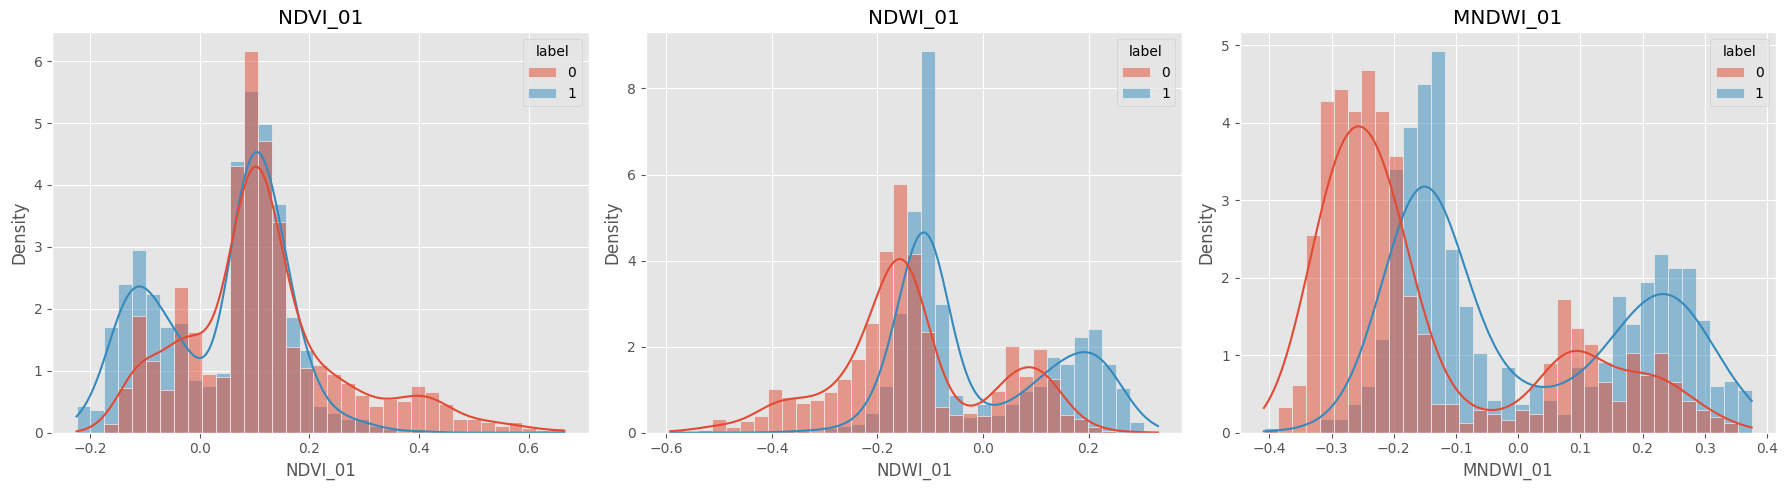

In [24]:
# ============================================
# Spectral Index Distributions
# ============================================

indices = ["NDVI_01", "NDWI_01", "MNDWI_01"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, feature in zip(axes, indices):

    sns.histplot(
        data=train,
        x=feature,
        hue="label",
        bins=35,
        kde=True,
        stat="density",
        common_norm=False,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

In [25]:
# ============================================
# Mean Spectral Index Values
# ============================================

results = []

for feature in ["NDVI_01", "NDWI_01", "MNDWI_01"]:

    pond = train.loc[train.label == 1, feature].mean()
    other = train.loc[train.label == 0, feature].mean()

    results.append({
        "Index": feature,
        "Pond Mean": pond,
        "Other Mean": other,
        "Difference": pond - other
    })

pd.DataFrame(results)

,Index,Pond Mean,Other Mean,Difference
0,NDVI_01,0.037634,0.117445,-0.079811
1,NDWI_01,-0.009606,-0.134003,0.124397
2,MNDWI_01,0.005024,-0.147165,0.152189


In [26]:
# ============================================
# Temporal Statistics for NIR
# ============================================

nir_cols = [f"nir_{i:02d}" for i in range(1, 13)]

train["nir_mean"] = train[nir_cols].mean(axis=1)
train["nir_std"] = train[nir_cols].std(axis=1)
train["nir_min"] = train[nir_cols].min(axis=1)
train["nir_max"] = train[nir_cols].max(axis=1)
train["nir_range"] = train["nir_max"] - train["nir_min"]

print(train[
    ["nir_mean","nir_std","nir_min","nir_max","nir_range"]
].head())

      nir_mean      nir_std  nir_min  nir_max  nir_range
0  1660.583333   372.514419     1303     2310       1007
1  3653.916667  1607.611750     1942     6567       4625
2  1857.666667   772.172535     1240     3664       2424
3  2469.166667   698.368336     1543     3468       1925
4  1616.166667   391.566280     1262     2432       1170


In [27]:
# ============================================
# Compare Temporal Features
# ============================================

features = [
    "nir_mean",
    "nir_std",
    "nir_min",
    "nir_max",
    "nir_range"
]

results = []

for feature in features:

    pond = train.loc[
        train.label==1,
        feature
    ].mean()

    other = train.loc[
        train.label==0,
        feature
    ].mean()

    results.append({

        "Feature":feature,

        "Pond":round(pond,2),

        "Other":round(other,2),

        "Difference":round(pond-other,2)

    })

pd.DataFrame(results)

,Feature,Pond,Other,Difference
0,nir_mean,1893.73,2939.90,-1046.18
1,nir_std,559.02,729.08,-170.07
2,nir_min,1243.43,2041.46,-798.03
3,nir_max,2933.72,4243.19,-1309.47
4,nir_range,1690.29,2201.73,-511.44


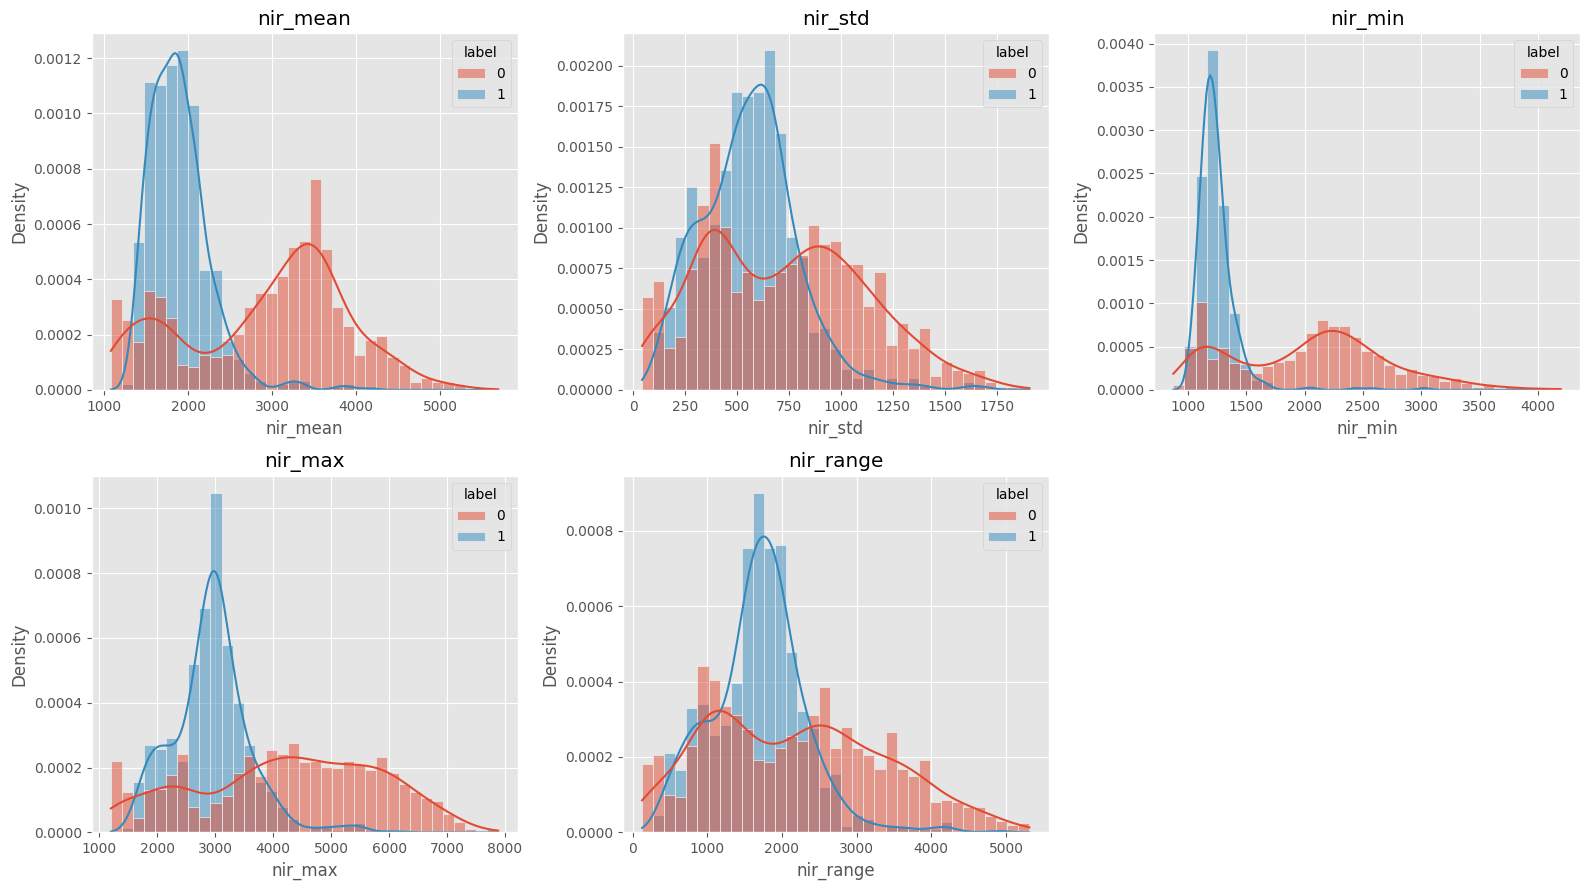

In [28]:
# ============================================
# Distribution of Temporal Features
# ============================================

features = [
    "nir_mean",
    "nir_std",
    "nir_min",
    "nir_max",
    "nir_range"
]

fig, axes = plt.subplots(2,3, figsize=(16,9))

axes = axes.flatten()

for ax, feature in zip(axes, features):

    sns.histplot(
        data=train,
        x=feature,
        hue="label",
        bins=35,
        kde=True,
        stat="density",
        common_norm=False,
        ax=ax
    )

    ax.set_title(feature)

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

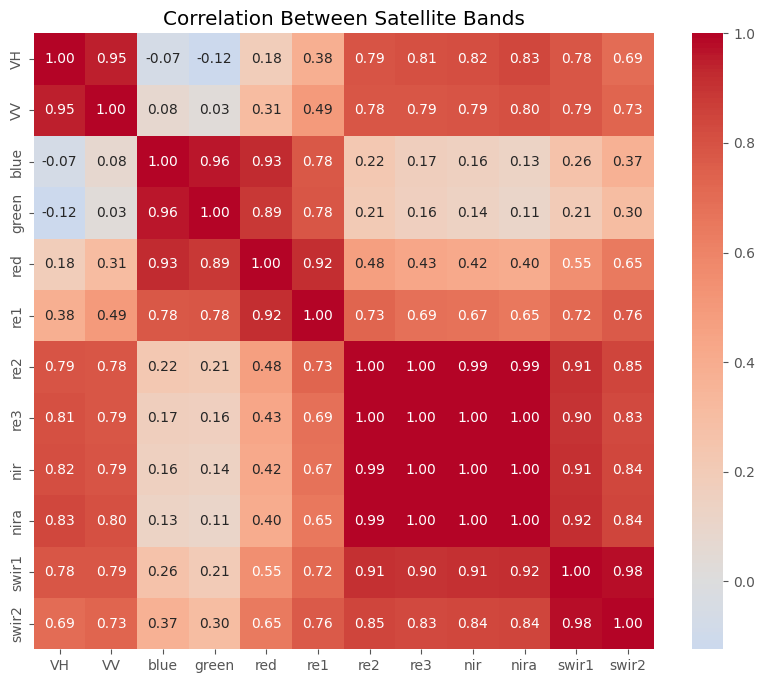

In [29]:
# ==========================================================
# CORRELATION ANALYSIS OF RAW BANDS (YEARLY MEANS)
# ==========================================================

# Compute yearly mean for each band
bands = [
    "VH","VV","blue","green","red",
    "re1","re2","re3",
    "nir","nira","swir1","swir2"
]

corr_df = pd.DataFrame()

for band in bands:
    cols = [f"{band}_{i:02d}" for i in range(1,13)]
    corr_df[band] = train[cols].mean(axis=1)

corr = corr_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Satellite Bands")
plt.show()

In [30]:
# ==========================================================
# STRONGEST CORRELATIONS
# ==========================================================

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool))
        .stack()
        .reset_index()
)

corr_pairs.columns = ["Feature 1","Feature 2","Correlation"]

corr_pairs["Abs"] = corr_pairs["Correlation"].abs()

corr_pairs.sort_values(
    "Abs",
    ascending=False,
    inplace=True
)

corr_pairs.head(20)

,Feature 1,Feature 2,Correlation,Abs
51,re2,re3,0.997649,0.997649
56,re3,nir,0.996717,0.996717
60,nir,nira,0.996397,0.996397
57,re3,nira,0.996198,0.996198
52,re2,nir,0.993459,0.993459
53,re2,nira,0.991401,0.991401
65,swir1,swir2,0.977403,0.977403
21,blue,green,0.964386,0.964386
0,VH,VV,0.945750,0.945750
22,blue,red,0.925429,0.925429


In [31]:
from sklearn.ensemble import RandomForestClassifier

# ============================
# QUICK FEATURE IMPORTANCE
# ============================

X = train.drop(columns=["ID", "label"])
y = train["label"]

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(30)

,Feature,Importance
76,nir_07,0.050550
91,re2_08,0.048472
92,re3_08,0.038780
88,nir_08,0.038412
77,nira_07,0.038294
79,re2_07,0.036025
70,swir1_06,0.031128
89,nira_08,0.028554
94,swir1_08,0.027009
82,swir1_07,0.023418


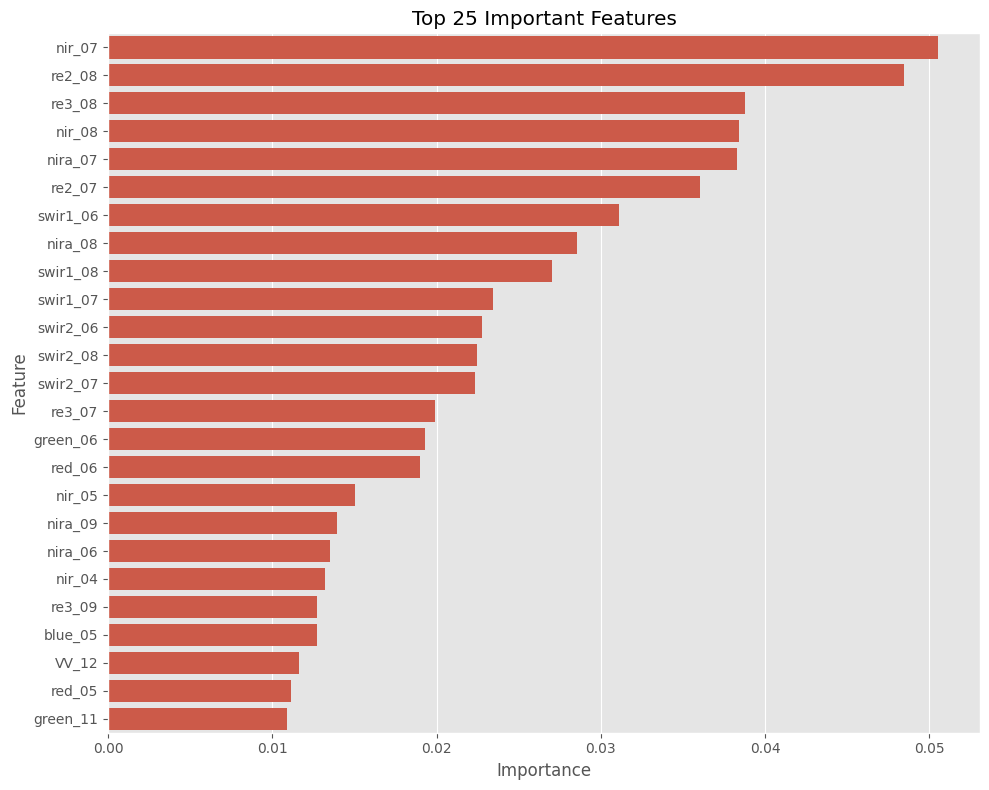

In [32]:
# ============================
# TOP 25 FEATURES
# ============================

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(25),
    y="Feature",
    x="Importance"
)

plt.title("Top 25 Important Features")
plt.tight_layout()
plt.show()

In [33]:
# ==========================================================
# FEATURE ENGINEERING PIPELINE
# ==========================================================

import numpy as np
import pandas as pd

from typing import List

In [34]:
# ==========================================================
# BAND DEFINITIONS
# ==========================================================

RADAR_BANDS = [
    "VH",
    "VV"
]

OPTICAL_BANDS = [
    "blue",
    "green",
    "red",
    "re1",
    "re2",
    "re3",
    "nir",
    "nira",
    "swir1",
    "swir2"
]

ALL_BANDS = RADAR_BANDS + OPTICAL_BANDS

MONTHS = [f"{i:02d}" for i in range(1,13)]

print(ALL_BANDS)

['VH', 'VV', 'blue', 'green', 'red', 're1', 're2', 're3', 'nir', 'nira', 'swir1', 'swir2']


In [35]:
# ==========================================================
# CLEAN MISSING VALUES
# ==========================================================

def clean_missing(df):
    """
    Replace competition sentinel value (-9999)
    with NaN.
    """

    df = df.copy()

    feature_cols = [
        c for c in df.columns
        if c not in ["ID", "label"]
    ]

    df[feature_cols] = df[feature_cols].replace(
        -9999,
        np.nan
    )

    return df

In [36]:
# ==========================================================
# COMPUTE SPECTRAL INDICES
# ==========================================================

def compute_indices(df):

    df = df.copy()

    eps = 1e-6

    for month in MONTHS:

        # NDVI
        df[f"NDVI_{month}"] = (
            (df[f"nir_{month}"] - df[f"red_{month}"]) /
            (df[f"nir_{month}"] + df[f"red_{month}"] + eps)
        )

        # NDWI
        df[f"NDWI_{month}"] = (
            (df[f"green_{month}"] - df[f"nir_{month}"]) /
            (df[f"green_{month}"] + df[f"nir_{month}"] + eps)
        )

        # MNDWI
        df[f"MNDWI_{month}"] = (
            (df[f"green_{month}"] - df[f"swir1_{month}"]) /
            (df[f"green_{month}"] + df[f"swir1_{month}"] + eps)
        )

    return df

In [37]:
# ==========================================================
# TEST FIRST PART OF PIPELINE
# ==========================================================

train_fe = clean_missing(train)

train_fe = compute_indices(train_fe)

print(train_fe.shape)

train_fe.filter(regex="NDVI|NDWI|MNDWI").head()

(1821, 187)


,NDVI_01,NDWI_01,MNDWI_01,NDVI_02,NDWI_02,MNDWI_02,NDVI_03,NDWI_03,MNDWI_03,NDVI_04,NDWI_04,MNDWI_04,NDVI_05,NDWI_05,MNDWI_05,NDVI_06,NDWI_06,MNDWI_06,NDVI_07,NDWI_07,MNDWI_07,NDVI_08,NDWI_08,MNDWI_08,NDVI_09,NDWI_09,MNDWI_09,NDVI_10,NDWI_10,MNDWI_10,NDVI_11,NDWI_11,MNDWI_11,NDVI_12,NDWI_12,MNDWI_12
0,-0.110026,0.114064,0.196659,-0.142766,0.150919,0.196835,-0.094719,0.061821,0.301113,-0.083189,0.036210,0.302605,-0.024081,0.013242,0.266418,-0.186883,0.184056,0.287002,-0.143932,0.160000,0.165379,-0.141068,0.185116,0.171561,-0.016949,0.013126,0.266100,-0.085794,0.105722,0.239084,-0.093001,0.149281,0.199249,-0.076465,0.133809,0.165656
1,0.065749,-0.126725,-0.189567,0.064110,-0.122219,-0.177808,0.092950,-0.133675,-0.148352,0.062903,-0.128793,-0.174325,0.100294,-0.155960,-0.194372,0.349461,-0.347258,-0.229881,0.641135,-0.562827,-0.266813,0.632196,-0.543160,-0.240221,0.567576,-0.500713,-0.229414,0.393155,-0.392414,-0.267208,0.274994,-0.293208,-0.315336,0.080383,-0.126078,-0.172449
2,0.286517,-0.219504,-0.152512,0.199036,-0.176150,-0.044487,-0.144867,0.223126,0.231354,-0.100798,0.181788,0.158848,-0.020298,0.075351,0.055138,-0.059880,0.109794,0.164728,-0.036201,0.099068,0.173913,-0.041338,0.112993,0.137910,0.000825,0.051369,0.160288,-0.014354,0.080904,0.164744,0.002528,0.065410,0.145391,-0.059197,0.112367,0.149828
3,0.077020,-0.138206,-0.125421,0.076923,-0.135620,-0.131163,0.065245,-0.101536,-0.098223,0.059753,-0.089689,-0.128760,0.207799,-0.199779,-0.118561,0.322362,-0.288679,-0.147300,0.405024,-0.350275,-0.190288,0.388589,-0.345490,-0.178676,0.373116,-0.342493,-0.192665,0.303156,-0.295823,-0.199311,0.201771,-0.211651,-0.187212,0.168015,-0.225774,-0.248303
4,-0.121103,0.130519,0.201104,-0.118785,0.142774,0.214528,-0.123125,0.132612,0.198169,-0.138509,0.124049,0.212104,-0.048861,0.034343,0.223904,-0.073280,0.063234,0.280740,-0.192515,0.224017,0.140261,-0.178653,0.227662,0.166958,0.065732,-0.057851,0.261503,-0.084784,0.097410,0.195339,-0.101440,0.154912,0.172260,-0.091816,0.152437,0.207154


In [38]:
# ==========================================================
# TEMPORAL AGGREGATION
# ==========================================================

def aggregate_temporal_features(df, feature_names):

    df = df.copy()

    for feature in feature_names:

        cols = [f"{feature}_{m}" for m in MONTHS]

        values = df[cols]

        df[f"{feature}_mean"] = values.mean(axis=1)

        df[f"{feature}_std"] = values.std(axis=1)

        df[f"{feature}_min"] = values.min(axis=1)

        df[f"{feature}_max"] = values.max(axis=1)

        df[f"{feature}_median"] = values.median(axis=1)

        df[f"{feature}_range"] = (
            df[f"{feature}_max"] -
            df[f"{feature}_min"]
        )

        df[f"{feature}_valid_months"] = values.notna().sum(axis=1)

    return df

In [39]:
# ==========================================================
# AGGREGATE ALL FEATURES
# ==========================================================

TEMPORAL_FEATURES = (
    ALL_BANDS +
    ["NDVI", "NDWI", "MNDWI"]
)

train_fe = aggregate_temporal_features(
    train_fe,
    TEMPORAL_FEATURES
)

print(train_fe.shape)

(1821, 287)


In [40]:
# ==========================================================
# CHECK NEW FEATURES
# ==========================================================

new_cols = [
    c for c in train_fe.columns
    if c.endswith((
        "_mean",
        "_std",
        "_min",
        "_max",
        "_median",
        "_range",
        "_valid_months"
    ))
]

print(f"Total aggregated features: {len(new_cols)}")

train_fe[new_cols].head()

Total aggregated features: 105


,nir_mean,nir_std,nir_min,nir_max,nir_range,VH_mean,VH_std,VH_min,VH_max,VH_median,VH_range,VH_valid_months,VV_mean,VV_std,VV_min,VV_max,VV_median,VV_range,VV_valid_months,blue_mean,blue_std,blue_min,blue_max,blue_median,blue_range,blue_valid_months,green_mean,green_std,green_min,green_max,green_median,green_range,green_valid_months,red_mean,red_std,red_min,red_max,red_median,red_range,red_valid_months,re1_mean,re1_std,re1_min,re1_max,re1_median,re1_range,re1_valid_months,re2_mean,re2_std,re2_min,re2_max,re2_median,re2_range,re2_valid_months,re3_mean,re3_std,re3_min,re3_max,re3_median,re3_range,re3_valid_months,nir_median,nir_valid_months,nira_mean,nira_std,nira_min,nira_max,nira_median,nira_range,nira_valid_months,swir1_mean,swir1_std,swir1_min,swir1_max,swir1_median,swir1_range,swir1_valid_months,swir2_mean,swir2_std,swir2_min,swir2_max,swir2_median,swir2_range,swir2_valid_months,NDVI_mean,NDVI_std,NDVI_min,NDVI_max,NDVI_median,NDVI_range,NDVI_valid_months,NDWI_mean,NDWI_std,NDWI_min,NDWI_max,NDWI_median,NDWI_range,NDWI_valid_months,MNDWI_mean,MNDWI_std,MNDWI_min,MNDWI_max,MNDWI_median,MNDWI_range,MNDWI_valid_months
0,1660.583333,372.514419,1303,2310,1007,-28.925385,2.772340,-36.058930,-25.347438,-28.475286,10.711493,12,-22.094435,1.235704,-23.955628,-19.631005,-22.354995,4.324623,12,1833.750000,194.958329,1639,2187,1763.0,548,12,2035.500000,230.329606,1719,2396,1973.0,677,12,2011.666667,339.248188,1626,2560,1886.5,934,12,2033.500000,353.770727,1689,2606,1922.0,917,12,1703.416667,374.805758,1324,2301,1545.0,977,12,1717.833333,386.099571,1349,2356,1556.0,1007,12,1472.0,12,1582.000000,351.182677,1253,2252,1416.0,999,12,1267.333333,66.748283,1154,1374,1263.0,220,12,1200.583333,46.932172,1141,1286,1186.5,145,12,-0.099906,0.049425,-0.186883,-0.016949,-0.093860,0.169934,12,0.108947,0.063206,0.013126,0.185116,0.123936,0.171990,12,0.229805,0.053238,0.165379,0.302605,0.219167,0.137227,12
1,3653.916667,1607.611750,1942,6567,4625,-17.748098,2.383521,-21.769029,-13.722553,-18.289234,8.046476,12,-9.156899,1.830953,-11.374729,-6.280759,-9.498751,5.093970,12,1569.166667,246.709558,1328,2045,1517.5,717,12,1839.916667,272.024885,1509,2354,1793.5,845,12,1860.916667,423.007728,1412,2689,1745.0,1277,12,2344.750000,357.454161,1747,2845,2459.0,1098,12,3327.833333,1381.664269,1802,5762,2960.5,3960,12,3569.583333,1603.924871,1837,6463,3067.5,4626,12,3113.0,12,3713.500000,1632.573679,1918,6546,3156.0,4628,12,2864.416667,407.717696,2176,3438,2931.5,1262,12,2328.916667,431.569537,1811,3169,2209.0,1358,12,0.277075,0.233838,0.062903,0.641135,0.187644,0.578232,12,-0.286086,0.177505,-0.562827,-0.122219,-0.224584,0.440608,12,-0.217145,0.049406,-0.315336,-0.148352,-0.211893,0.166984,12
2,1857.666667,772.172535,1240,3664,2424,-28.214195,3.540516,-32.687598,-20.964854,-28.661913,11.722744,12,-19.200454,4.580989,-22.534477,-8.792675,-20.183631,13.741802,12,1670.666667,188.887332,1437,1982,1609.0,545,12,1983.750000,235.302175,1673,2345,1961.0,672,12,1755.666667,230.025822,1503,2161,1720.0,658,12,2045.166667,441.267561,1483,2935,1930.0,1452,12,1860.250000,648.683019,1287,3384,1637.0,2097,12,1901.583333,675.438640,1246,3451,1655.5,2205,12,1565.5,12,1801.166667,711.619259,1213,3470,1571.0,2257,12,1641.750000,586.534836,1237,3189,1451.5,1952,12,1425.583333,347.773557,1168,2397,1315.5,1229,12,0.000998,0.121945,-0.144867,0.286517,-0.028250,0.431384,12,0.059710,0.129917,-0.219504,0.223126,0.089986,0.442630,12,0.112095,0.108323,-0.152512,0.231354,0.154338,0.383866,12
3,2469.166667,698.368336,1543,3468,1925,-17.615523,1.322636,-19.614806,-15.318855,-17.564088,4.295951,12,-6.370493,1.846551,-8.942481,-3.566426,-6.571552,5.376055,12,1339.083333,92.267850,1184,1529,1335.5,345,12,1496.666667,149.223647,1289,1687,1521.0,398,12,1508.500000,127.335991,1350,1748,1493.0,398,12,1774.166667,233.823490,1486,2104,1780.0,618,12,2157.750000,577.725654,1434,2988,2088.5,1554,12,2299.083333,674.757796,1447,3287,2215.0,1840,12,2516.5,12,2418.166667,712.267931,1506,3474,2419.5,1968,12,2097

In [41]:
# ==========================================================
# COMPETITION-GRADE TEMPORAL AGGREGATION
# ==========================================================

def aggregate_temporal_features(df, feature_names):

    df = df.copy()

    eps = 1e-6

    for feature in feature_names:

        cols = [f"{feature}_{m}" for m in MONTHS]

        values = df[cols]

        # Basic statistics
        df[f"{feature}_mean"] = values.mean(axis=1)
        df[f"{feature}_std"] = values.std(axis=1)
        df[f"{feature}_min"] = values.min(axis=1)
        df[f"{feature}_max"] = values.max(axis=1)
        df[f"{feature}_median"] = values.median(axis=1)

        # Range
        df[f"{feature}_range"] = (
            df[f"{feature}_max"] -
            df[f"{feature}_min"]
        )

        # Valid observations
        df[f"{feature}_valid_months"] = values.notna().sum(axis=1)

        # Coefficient of Variation
        df[f"{feature}_cv"] = (
            df[f"{feature}_std"] /
            (df[f"{feature}_mean"].abs() + eps)
        )

        # Interquartile Range
        q1 = values.quantile(0.25, axis=1)
        q3 = values.quantile(0.75, axis=1)

        df[f"{feature}_iqr"] = q3 - q1

    return df

In [42]:
# ==========================================================
# REBUILD TEMPORAL FEATURES
# ==========================================================

train_fe = clean_missing(train)

train_fe = compute_indices(train_fe)

train_fe = aggregate_temporal_features(
    train_fe,
    TEMPORAL_FEATURES
)

print(train_fe.shape)

(1821, 317)


In [43]:
# ==========================================================
# VERIFY NEW FEATURES
# ==========================================================

extra_cols = [
    c for c in train_fe.columns
    if c.endswith(("_cv", "_iqr"))
]

print(f"New CV/IQR Features: {len(extra_cols)}")

train_fe[extra_cols].head()

New CV/IQR Features: 30


,VH_cv,VH_iqr,VV_cv,VV_iqr,blue_cv,blue_iqr,green_cv,green_iqr,red_cv,red_iqr,re1_cv,re1_iqr,re2_cv,re2_iqr,re3_cv,re3_iqr,nir_cv,nir_iqr,nira_cv,nira_iqr,swir1_cv,swir1_iqr,swir2_cv,swir2_iqr,NDVI_cv,NDVI_iqr,NDWI_cv,NDWI_iqr,MNDWI_cv,MNDWI_iqr
0,0.095845,2.409796,0.055928,1.030814,0.106317,354.75,0.113156,358.25,0.168640,549.75,0.173971,560.25,0.220032,635.00,0.224760,670.75,0.224327,685.00,0.221987,651.5,0.052668,97.25,0.039091,50.75,0.494709,0.059984,0.580148,0.097771,0.231667,0.081179
1,0.134297,3.139143,0.199953,2.454043,0.157223,321.25,0.147846,204.00,0.227311,457.25,0.152449,508.50,0.415184,1933.75,0.449331,2115.25,0.439969,2024.25,0.439632,2167.0,0.142339,636.50,0.185309,379.75,0.843949,0.360036,0.620460,0.291212,0.227523,0.069932
2,0.125487,3.247159,0.238588,2.395130,0.113061,301.75,0.118615,371.25,0.131019,391.00,0.215761,536.25,0.348707,410.00,0.355198,432.75,0.415668,403.25,0.395088,284.0,0.357262,241.00,0.243952,188.75,122.088346,0.060619,2.175779,0.050624,0.966337,0.047515
3,0.075084,1.649436,0.289860,3.229582,0.068904,120.50,0.099704,285.75,0.084412,138.00,0.131793,448.50,0.267744,1054.25,0.293490,1225.75,0.282836,1286.00,0.294549,1298.0,0.174961,703.75,0.112847,290.25,0.606605,0.258055,0.425964,0.169931,0.269823,0.062957
4,0.135257,4.632380,0.080953,2.740286,0.100936,252.00,0.095922,298.25,0.137038,376.00,0.148927,419.00,0.194398,418.00,0.204061,412.50,0.242281,429.75,0.210032,401.5,0.080863,145.25,0.082188,122.50,0.661121,0.045063,0.662409,0.064190,0.186606,0.027303


In [44]:
# ==========================================================
# BUILD FINAL TRAIN & TEST DATASETS
# ==========================================================

train_fe = clean_missing(train)
test_fe  = clean_missing(test)

train_fe = compute_indices(train_fe)
test_fe  = compute_indices(test_fe)

train_fe = aggregate_temporal_features(
    train_fe,
    TEMPORAL_FEATURES
)

test_fe = aggregate_temporal_features(
    test_fe,
    TEMPORAL_FEATURES
)

print("Train:", train_fe.shape)
print("Test :", test_fe.shape)

Train: (1821, 317)
Test : (1030, 316)


In [45]:
# ==========================================================
# VERIFY TRAIN / TEST CONSISTENCY
# ==========================================================

train_cols = set(train_fe.columns) - {"label"}
test_cols = set(test_fe.columns)

print("Missing in test :", train_cols - test_cols)
print("Missing in train:", test_cols - train_cols)

Missing in test : set()
Missing in train: set()


In [46]:
# ==========================================================
# STAGE 1 - REMOVE CONSTANT FEATURES
# ==========================================================

from sklearn.feature_selection import VarianceThreshold

# Separate X and y
X = train_fe.drop(columns=["ID", "label"])
y = train_fe["label"]

selector = VarianceThreshold(threshold=0.0)

selector.fit(X)

selected_columns = X.columns[selector.get_support()]

removed_columns = X.columns[~selector.get_support()]

print("="*60)
print(f"Original Features : {X.shape[1]}")
print(f"Remaining Features: {len(selected_columns)}")
print(f"Removed Features  : {len(removed_columns)}")
print("="*60)

if len(removed_columns) > 0:
    print("\nRemoved Constant Features:")
    print(list(removed_columns))
else:
    print("\nNo constant features found.")

Original Features : 315
Remaining Features: 300
Removed Features  : 15

Removed Constant Features:
['VH_valid_months', 'VV_valid_months', 'blue_valid_months', 'green_valid_months', 'red_valid_months', 're1_valid_months', 're2_valid_months', 're3_valid_months', 'nir_valid_months', 'nira_valid_months', 'swir1_valid_months', 'swir2_valid_months', 'NDVI_valid_months', 'NDWI_valid_months', 'MNDWI_valid_months']


In [49]:
print(df.columns.tolist())

['Month', 'Pond', 'Other']


In [50]:
df.columns

Index(['Month', 'Pond', 'Other'], dtype='object')

In [48]:
print(df.shape)

(12, 3)


In [53]:
print(df["target"].value_counts())

KeyError: 'target'

In [54]:
missing = df.isnull().sum()
print(missing[missing > 0].sort_values())

Series([], dtype: int64)


In [55]:
df.head()

,Month,Pond,Other
0,01,-26.69,-24.49
1,02,-27.48,-24.50
2,03,-30.25,-24.54
3,04,-30.63,-22.80
4,05,-30.25,-22.21


In [56]:
df.dtypes

,0
Month,object
Pond,float64
Other,float64


In [57]:
df.dtypes

,0
Month,object
Pond,float64
Other,float64
